# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [3]:
# Carregar as bases salvas no M17
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
X_test  = pd.read_csv("X_test.csv")
y_test  = pd.read_csv("y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\ny_train:")
print(y_train.value_counts())
print("\ny_test:")
print(y_test.value_counts())

X_train: (270, 7)
X_test: (33, 7)

y_train:
Credit Score_encoded
1    90
0    90
2    90
Name: count, dtype: int64

y_test:
Credit Score_encoded
1    23
0     5
2     5
Name: count, dtype: int64


# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

### Questão 2 - Passo a passo da Arvore de Decisao

1. Carregar os dados ja tratados e balanceados

2. Treinar o modelo com DecisionTreeClassifier nos dados de treino

3. Avaliar no treino com acuracia e matriz de confusao

4. Avaliar no teste com as mesmas metricas e comparar com o treino
   (se o treino for muito melhor que o teste, o modelo decorou)

5. Plotar a arvore para visualizar as decisoes

6. Identificar as variaveis mais importantes (feature importance)

7. Melhorar o modelo limitando a profundidade da arvore (max_depth)
   para evitar overfitting, ou usando apenas as variaveis mais importantes

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [6]:
# Criar e treinar o modelo
arvore = DecisionTreeClassifier(criterion='gini', random_state=0)
arvore.fit(X_train, y_train)

# Acuracia no treino
y_pred_train = arvore.predict(X_train)
acuracia_train = accuracy_score(y_train, y_pred_train)
print(f"Acuracia treino: {acuracia_train:.4f}")

Acuracia treino: 1.0000


# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

Acuracia treino: 1.0000
Acuracia teste:  0.9697


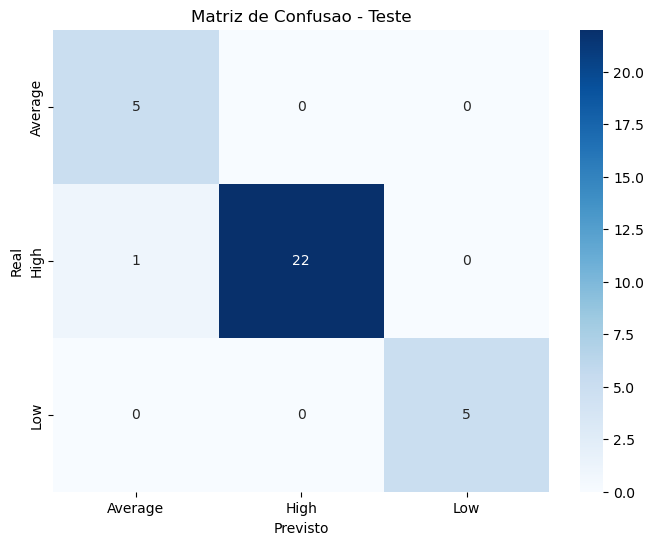

              precision    recall  f1-score   support

     Average       0.83      1.00      0.91         5
        High       1.00      0.96      0.98        23
         Low       1.00      1.00      1.00         5

    accuracy                           0.97        33
   macro avg       0.94      0.99      0.96        33
weighted avg       0.97      0.97      0.97        33



In [8]:
# Prever e avaliar no teste
y_pred_test = arvore.predict(X_test)
acuracia_test = accuracy_score(y_test, y_pred_test)
print(f"Acuracia treino: {acuracia_train:.4f}")
print(f"Acuracia teste:  {acuracia_test:.4f}")

# Matriz de confusao
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Average', 'High', 'Low'],
            yticklabels=['Average', 'High', 'Low'])
plt.title('Matriz de Confusao - Teste')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

# Relatorio completo
print(classification_report(y_test, y_pred_test,
      target_names=['Average', 'High', 'Low']))

### Questao 4 - Avaliacao no Teste

**Acuracia treino: 100%**
**Acuracia teste: 96.97%**

A queda de 100% para 97% e pequena, indicando leve overfitting
mas sem impacto grave. O modelo generalizou bem.

**Lendo a matriz de confusao:**
- Average: 5 acertos de 5, sem erros
- High: 22 acertos de 23, 1 confundido com Average
- Low: 5 acertos de 5, sem erros

Apenas 1 erro em 33 previsoes. Desempenho excelente.

**Comparando com o Naive Bayes:**
- Naive Bayes: 93.94% de acuracia no teste
- Arvore de Decisao: 96.97% de acuracia no teste

A arvore superou o Naive Bayes em 3 pontos percentuais.

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

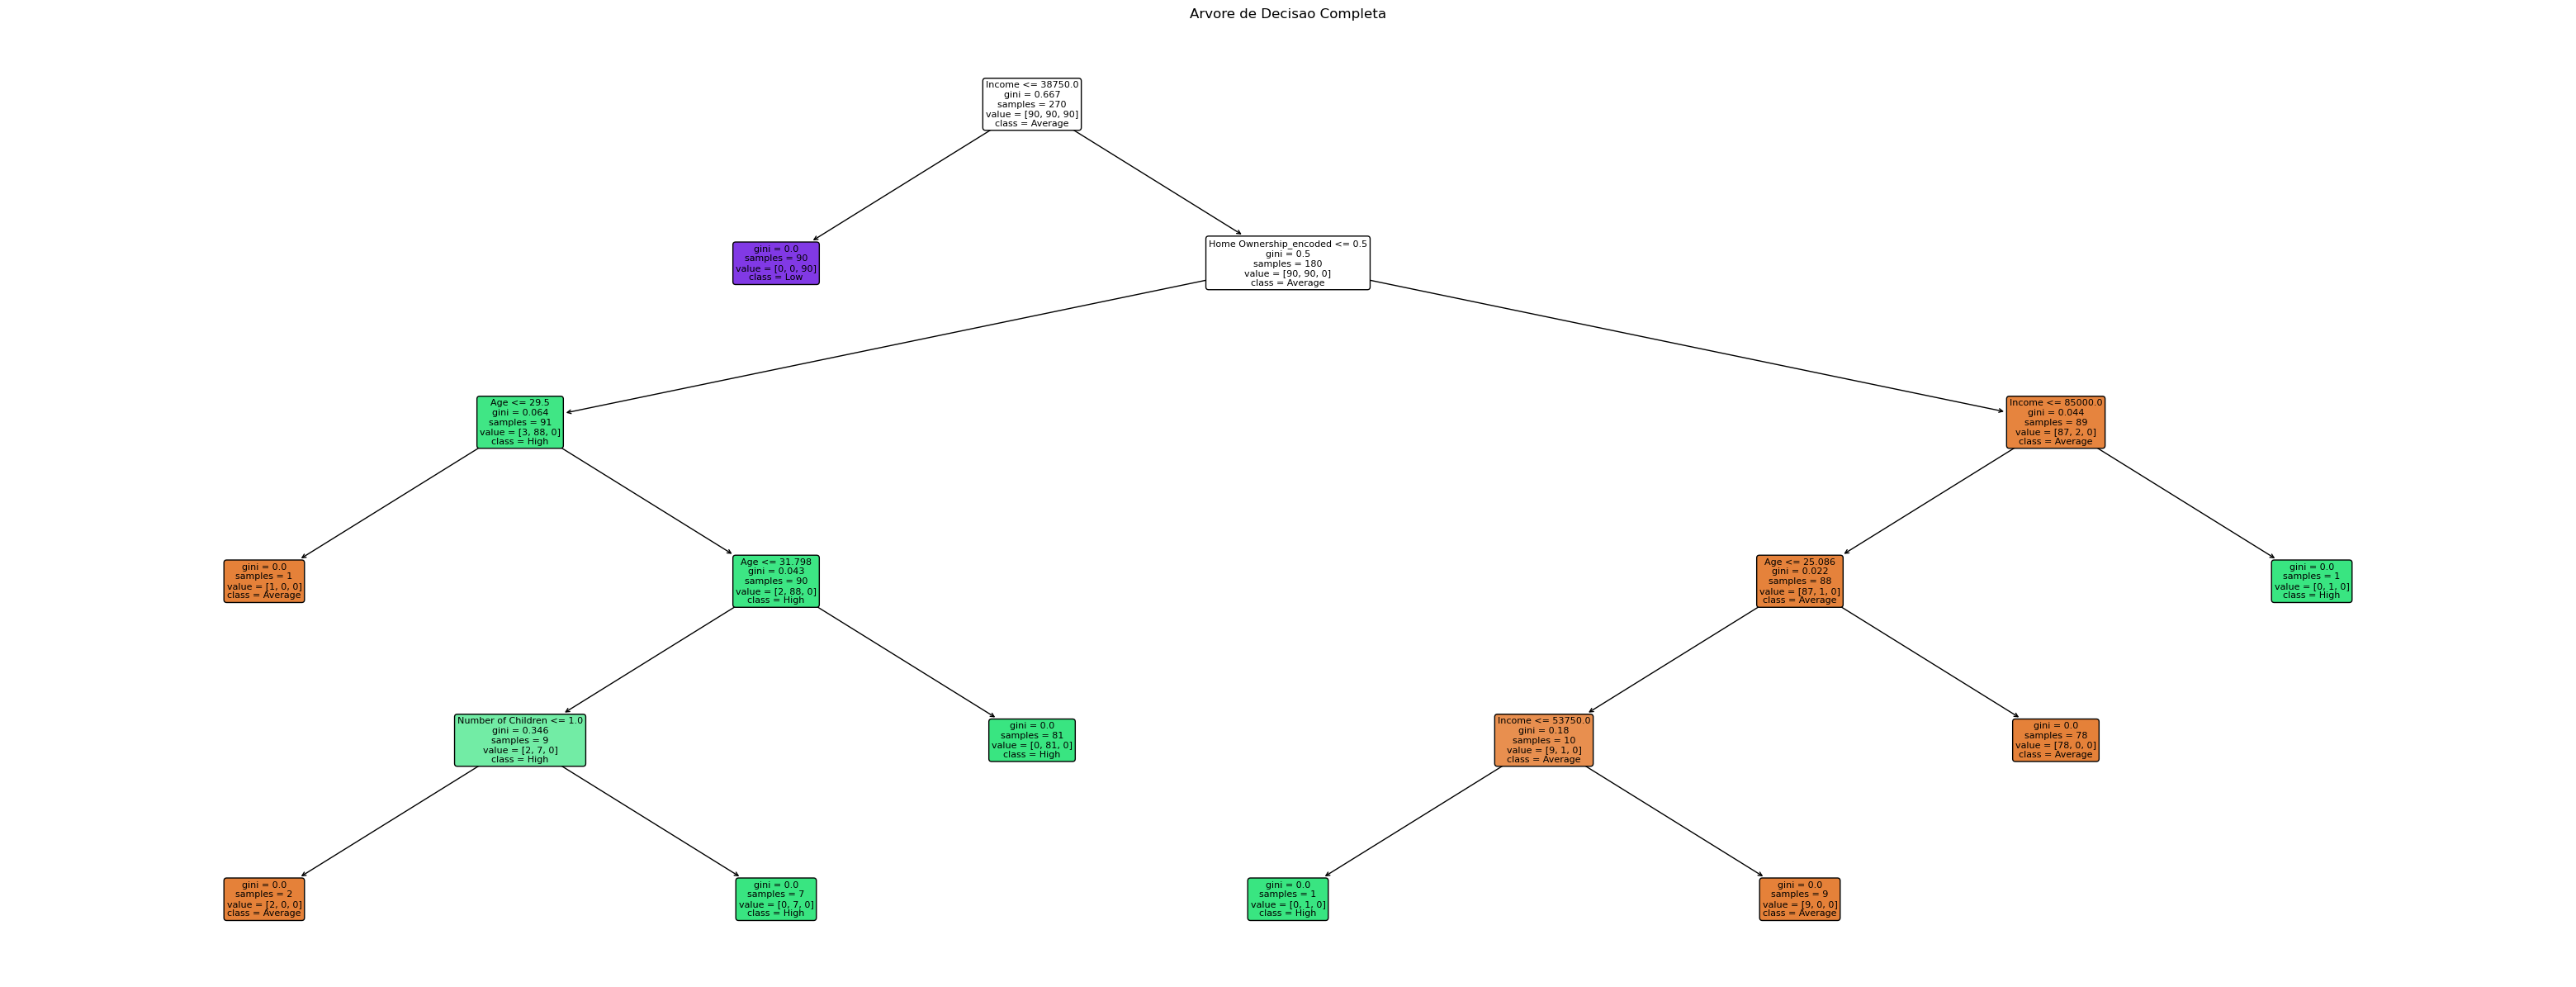

Profundidade da arvore: 5
Numero de folhas: 9


In [11]:
plt.figure(figsize=(40, 15))
plot_tree(arvore,
          feature_names=X_train.columns.tolist(),
          class_names=['Average', 'High', 'Low'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Arvore de Decisao Completa')
plt.show()

print(f"Profundidade da arvore: {arvore.get_depth()}")
print(f"Numero de folhas: {arvore.get_n_leaves()}")

### Questao 5 - Arvore de Decisao

**Profundidade: 5**
**Numero de folhas: 9**

A arvore tem 5 niveis de perguntas e 9 decisoes finais.
E possivel fazer uma avaliacao visual sim:

- A primeira divisao usa Home Ownership, confirmando
  que essa e a variavel mais importante do modelo
- Os nos mais escuros (gini proximo de 0) sao os mais
  puros, ou seja, o modelo tem alta certeza nessa regiao
- A arvore nao e excessivamente profunda, o que ajuda
  a evitar overfitting muito severo
- Com 5 niveis a arvore ainda e interpretavel, diferente
  de arvores com 20+ niveis que se tornam impraticaveis
  de analisar visualmente

# 6) Identifique as 2 principais features do modelo.


Importancia das variaveis:
Income                    0.520738
Home Ownership_encoded    0.446043
Number of Children        0.017284
Age                       0.015935
Gender_encoded            0.000000
Education_encoded         0.000000
Marital Status_encoded    0.000000
dtype: float64


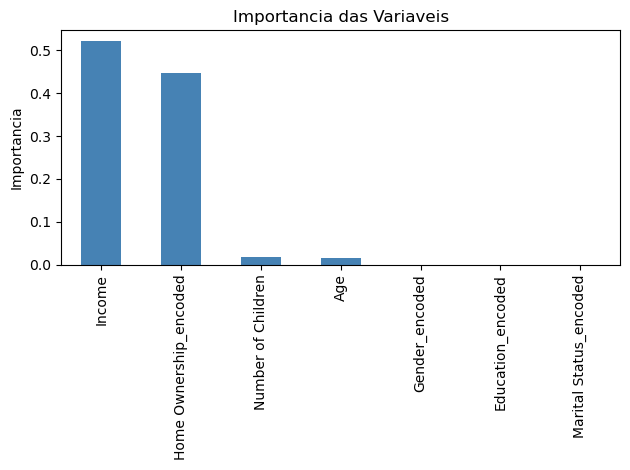

In [14]:
# Feature importance
importancias = pd.Series(
    arvore.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Importancia das variaveis:")
print(importancias)

# Grafico
importancias.plot(kind='bar', color='steelblue')
plt.title('Importancia das Variaveis')
plt.ylabel('Importancia')
plt.tight_layout()
plt.show()

### Questao 6 - Variaveis mais importantes

As 2 principais features do modelo sao:

1. Income (52.07%): A renda e o fator mais determinante
   do score de credito. Faz todo sentido: quem ganha mais
   tem mais capacidade de honrar dividas.

2. Home Ownership_encoded (44.60%): Ter casa propria
   indica estabilidade financeira e tambem reflete
   renda mais alta historicamente.

Juntas essas duas variaveis explicam 96% do poder
preditivo do modelo. Gender, Education e Marital Status
nao foram usadas em nenhuma divisao da arvore.

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [19]:
# Selecionar apenas as 2 principais
X_train_2 = X_train[['Income', 'Home Ownership_encoded']]
X_test_2  = X_test[['Income', 'Home Ownership_encoded']]

# Treinar nova arvore
arvore_2 = DecisionTreeClassifier(criterion='gini', random_state=0)
arvore_2.fit(X_train_2, y_train)

# Avaliar
y_pred_train_2 = arvore_2.predict(X_train_2)
y_pred_test_2  = arvore_2.predict(X_test_2)

acuracia_train_2 = accuracy_score(y_train, y_pred_train_2)
acuracia_test_2  = accuracy_score(y_test, y_pred_test_2)

print(f"Acuracia treino (2 features): {acuracia_train_2:.4f}")
print(f"Acuracia teste  (2 features): {acuracia_test_2:.4f}")
print(f"\nAcuracia treino (7 features): {acuracia_train:.4f}")
print(f"Acuracia teste  (7 features): {acuracia_test:.4f}")

Acuracia treino (2 features): 0.9963
Acuracia teste  (2 features): 0.9394

Acuracia treino (7 features): 1.0000
Acuracia teste  (7 features): 0.9697


### Questao 7 - Arvore com 2 Features

**Acuracia treino: 99.63%**
**Acuracia teste: 93.94%**

Comparando com o modelo completo (7 features):
- Treino: 100% vs 99.63% (praticamente igual)
- Teste: 96.97% vs 93.94% (queda de 3 pontos)

O modelo com 7 features ainda performa melhor no teste.
Porem o modelo com 2 features tem vantagens importantes:

1. E mais simples e facil de explicar para um gestor
2. Usa menos dados para chegar a uma conclusao parecida
3. Confirma que Income e Home Ownership sao os pilares
   do score de credito nessa base

A escolha entre os dois depende do contexto: se precisar
de maxima acuracia, use 7 features. Se precisar de um
modelo explicavel e simples, 2 features ja sao suficientes.

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

### Questao 8 - Arvore de Decisao vs Naive Bayes

**Resultados no teste:**
- Naive Bayes:        93.94% de acuracia
- Arvore (7 features): 96.97% de acuracia
- Arvore (2 features): 93.94% de acuracia

A Arvore de Decisao com todas as features se adequou
melhor aos dados, superando o Naive Bayes em 3 pontos
percentuais de acuracia.

Isso ocorre porque o Naive Bayes assume que todas as
variaveis sao independentes entre si, o que nao e
verdade nessa base: Income e Home Ownership sao
altamente correlacionadas. A arvore nao faz essa
suposicao e consegue capturar essas relacoes melhor.

Alem disso a arvore identificou que 3 variaveis nao
contribuem em nada (Gender, Education, Marital Status),
algo que o Naive Bayes nao consegue fazer.

Para esse problema de credit score a Arvore de Decisao
e o algoritmo mais adequado.